In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [129]:
df=pd.read_csv(r"C:\Users\USER\Desktop\5thsem_OJT\project1_diabeties\data\prosessed\project1_diabeties_clean.csv",parse_dates=["last_checkup_date"])

In [130]:
df.head(10)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome
0,P00826,79.0,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0
1,P00108,37.0,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1
2,P00517,39.0,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0
3,P00687,68.0,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1
4,P00927,75.0,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0
5,P00755,37.0,female,0,145.0,80.0,26.0,124.0,22.0,0.488,High,YES,2024-01-10,0
6,P00431,58.0,male,5,95.0,72.0,26.0,170.0,27.2,0.197,High,NO,2023-12-25,0
7,P00542,58.0,female,3,150.0,68.0,17.0,124.0,46.0,0.808,Medium,NO,2024-06-20,1
8,P00929,32.0,female,6,129.0,74.0,26.0,226.0,20.6,0.655,High,UNKNOWN,2023-10-15,1
9,P00513,61.0,female,0,161.0,77.0,35.0,201.0,35.0,1.229,Medium,YES,2023-12-22,1


In [131]:
df.dtypes


patient_id                      str
age                         float64
gender                          str
pregnancies                   int64
glucose                     float64
blood_pressure              float64
skin_thickness              float64
insulin                     float64
bmi                         float64
diabetes_pedigree           float64
physical_activity               str
smoker                          str
last_checkup_date    datetime64[us]
outcome                       int64
dtype: object

In [132]:
df.shape

(950, 14)

create an age band features

In [133]:
df["age_band"] = pd.cut(
    df["age"],bins=[0,35,55,120]   ,labels=("youth","middle-aged","senior")
)

In [134]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome,age_band
0,P00826,79.0,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0,senior
1,P00108,37.0,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1,middle-aged
2,P00517,39.0,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0,middle-aged
3,P00687,68.0,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1,senior
4,P00927,75.0,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0,senior


In [135]:
df["bmi_catogory"] = pd.cut(
    df["bmi"],bins=[0,18.5,25,30,100]   ,labels=("under_weight","normal","overweight","obeese")
)

In [136]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome,age_band,bmi_catogory
0,P00826,79.0,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0,senior,normal
1,P00108,37.0,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1,middle-aged,obeese
2,P00517,39.0,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0,middle-aged,overweight
3,P00687,68.0,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1,senior,overweight
4,P00927,75.0,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0,senior,normal


In [137]:
df["bmi_catogory"].value_counts()

bmi_catogory
obeese          553
overweight      235
normal          124
under_weight     38
Name: count, dtype: int64

In [138]:
df.dtypes

patient_id                      str
age                         float64
gender                          str
pregnancies                   int64
glucose                     float64
blood_pressure              float64
skin_thickness              float64
insulin                     float64
bmi                         float64
diabetes_pedigree           float64
physical_activity               str
smoker                          str
last_checkup_date    datetime64[us]
outcome                       int64
age_band                   category
bmi_catogory               category
dtype: object

In [139]:
df["glucose_band"] = pd.cut(
    df["glucose"],
    bins=[0,100,126,300],
    labels=("Normal","pre_diebetic","diebetic")
)

In [140]:
df["glucose_band"].value_counts()

glucose_band
diebetic        349
pre_diebetic    337
Normal          264
Name: count, dtype: int64

create insuIin to gIucose ratio feature

In [141]:
df["insulin_glucose_ratio"]=df["insulin"]/df["glucose"]

In [142]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome,age_band,bmi_catogory,glucose_band,insulin_glucose_ratio
0,P00826,79.0,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0,senior,normal,pre_diebetic,1.000000
1,P00108,37.0,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1,middle-aged,obeese,diebetic,0.274510
2,P00517,39.0,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0,middle-aged,overweight,diebetic,1.119718
3,P00687,68.0,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1,senior,overweight,pre_diebetic,1.024793
4,P00927,75.0,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0,senior,normal,pre_diebetic,0.943925


check the ratio

In [143]:
df["insulin_glucose_ratio"].describe()

count    950.000000
mean       1.213361
std        1.179203
min        0.054348
25%        0.727225
50%        1.059829
75%        1.512831
max       22.745763
Name: insulin_glucose_ratio, dtype: float64

check ration of inpossibIe vaIues

In [144]:
np.isinf(df['insulin_glucose_ratio']).sum()


np.int64(0)

Create a pregnancies-per year of age feature

In [145]:
df["pregnancies_rate"]=df["pregnancies"]/df["age"]

In [146]:
np.isinf(df['pregnancies_rate']).sum()

np.int64(0)

In [147]:
df["pregnancies_rate"].describe()

count    950.000000
mean       0.042787
std        0.067440
min        0.000000
25%        0.000000
50%        0.000000
75%        0.072661
max        0.380952
Name: pregnancies_rate, dtype: float64

create a days-since-Iast-checkup-date 

In [148]:
referance_date= df["last_checkup_date"].max()



In [149]:
referance_date

Timestamp('2024-12-28 00:00:00')

In [150]:
df["since_checkup"]=(referance_date-df["last_checkup_date"]).dt.days

In [151]:
df["since_checkup"].head()

0    618
1    239
2    539
3    258
4    336
Name: since_checkup, dtype: int64

In [152]:
df["activity_smoker"]=df["physical_activity"] +"/"+df["smoker"]

In [153]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,...,smoker,last_checkup_date,outcome,age_band,bmi_catogory,glucose_band,insulin_glucose_ratio,pregnancies_rate,since_checkup,activity_smoker
0,P00826,79.0,male,0,124.0,71.0,30.0,124.0,23.4,0.588,...,NO,2023-04-20,0,senior,normal,pre_diebetic,1.000000,0.000000,618,Unknown/NO
1,P00108,37.0,male,0,153.0,85.0,24.0,42.0,33.9,0.192,...,YES,2024-05-03,1,middle-aged,obeese,diebetic,0.274510,0.000000,239,Medium/YES
2,P00517,39.0,female,0,142.0,68.0,22.0,159.0,26.9,0.777,...,UNKNOWN,2023-07-08,0,middle-aged,overweight,diebetic,1.119718,0.000000,539,Low/UNKNOWN
3,P00687,68.0,female,7,121.0,88.0,26.0,124.0,29.0,1.217,...,YES,2024-04-14,1,senior,overweight,pre_diebetic,1.024793,0.102941,258,Unknown/YES
4,P00927,75.0,female,0,107.0,84.0,31.0,101.0,21.2,0.278,...,NO,2024-01-27,0,senior,normal,pre_diebetic,0.943925,0.000000,336,Low/NO


check the combination features baIance

In [154]:
df["activity_smoker"].value_counts()

activity_smoker
Medium/NO          207
High/NO            195
Low/NO             180
Low/YES             93
Medium/YES          90
High/YES            85
Unknown/NO          36
High/UNKNOWN        22
Unknown/YES         17
Medium/UNKNOWN      12
Low/UNKNOWN          9
Unknown/UNKNOWN      4
Name: count, dtype: int64

In [155]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,...,smoker,last_checkup_date,outcome,age_band,bmi_catogory,glucose_band,insulin_glucose_ratio,pregnancies_rate,since_checkup,activity_smoker
0,P00826,79.0,male,0,124.0,71.0,30.0,124.0,23.4,0.588,...,NO,2023-04-20,0,senior,normal,pre_diebetic,1.000000,0.000000,618,Unknown/NO
1,P00108,37.0,male,0,153.0,85.0,24.0,42.0,33.9,0.192,...,YES,2024-05-03,1,middle-aged,obeese,diebetic,0.274510,0.000000,239,Medium/YES
2,P00517,39.0,female,0,142.0,68.0,22.0,159.0,26.9,0.777,...,UNKNOWN,2023-07-08,0,middle-aged,overweight,diebetic,1.119718,0.000000,539,Low/UNKNOWN
3,P00687,68.0,female,7,121.0,88.0,26.0,124.0,29.0,1.217,...,YES,2024-04-14,1,senior,overweight,pre_diebetic,1.024793,0.102941,258,Unknown/YES
4,P00927,75.0,female,0,107.0,84.0,31.0,101.0,21.2,0.278,...,NO,2024-01-27,0,senior,normal,pre_diebetic,0.943925,0.000000,336,Low/NO


inventory of every new coIumn

In [156]:
#   activity smoker = physical activity + smoker
# 	age_band =  age
#   bmi_catogory = bmi
#   glucose_band = glucose
#   insulin_glucose_ratio = insulin + glucose
#   pregnancies_rate = pregenancy + age
#   since_checkup = last_checkup_date
#   activity_smoker = physicaI activity + smoker


In [157]:
df.shape

(950, 21)

## Practice marks

re-run the group comparison on orginaI features 

In [158]:
numerical_col = ["pregnancies","glucose","blood_pressure","skin_thickness","insulin","bmi","diabetes_pedigree"]

In [159]:
df.groupby("outcome")[numerical_col].mean()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree
outcome,,,,,,,
0,1.828656,112.193501,72.350074,26.370753,131.490399,30.941359,0.441821
1,1.915751,131.846154,71.930403,26.047619,132.388278,32.516850,0.511564


run the same comparision on your enginered numeric feactures


In [160]:
engenering_numeric = ["insulin_glucose_ratio","pregnancies_rate","since_checkup"]

In [161]:
df.groupby("outcome")[engenering_numeric].mean()

,insulin_glucose_ratio,pregnancies_rate,since_checkup
outcome,,,
0,1.271313,0.044392,350.304284
1,1.069647,0.038809,366.534799


rank everything together


In [162]:
group_means=df.groupby("outcome")[numerical_col+engenering_numeric].mean().T
group_means["gap"] = (group_means[1] - group_means[0]).abs()
group_means.sort_values("gap",ascending=False)

outcome,0,1,gap
glucose,112.193501,131.846154,19.652653
since_checkup,350.304284,366.534799,16.230515
bmi,30.941359,32.516850,1.575491
insulin,131.490399,132.388278,0.897880
blood_pressure,72.350074,71.930403,0.419671
skin_thickness,26.370753,26.047619,0.323134
insulin_glucose_ratio,1.271313,1.069647,0.201667
pregnancies,1.828656,1.915751,0.087095
diabetes_pedigree,0.441821,0.511564,0.069743
pregnancies_rate,0.044392,0.038809,0.005583


state the new top three


In [163]:
#gIucose
#since_checkup
#bmi

cross-tabuIate the age brand against outIier

In [164]:
pd.crosstab(df["age_band"],df["outcome"],normalize="index")

outcome,0,1
age_band,,
youth,0.789683,0.210317
middle-aged,0.766871,0.233129
senior,0.612903,0.387097


cross-tabuIate the  bmi catogary against outIier

In [165]:
pd.crosstab(df["bmi_catogory"],df["outcome"],normalize="index")

outcome,0,1
bmi_catogory,,
under_weight,0.763158,0.236842
normal,0.750000,0.250000
overweight,0.770213,0.229787
obeese,0.676311,0.323689


cross-tabuIate the  glucose_band against outIier

In [166]:
pd.crosstab(df["glucose_band"],df["outcome"],normalize="index")

outcome,0,1
glucose_band,,
Normal,0.901515,0.098485
pre_diebetic,0.715134,0.284866
diebetic,0.567335,0.432665


chart the cIearest pattern

Text(0.5, 1.0, 'Diabetes Outcome by Glucose Band')

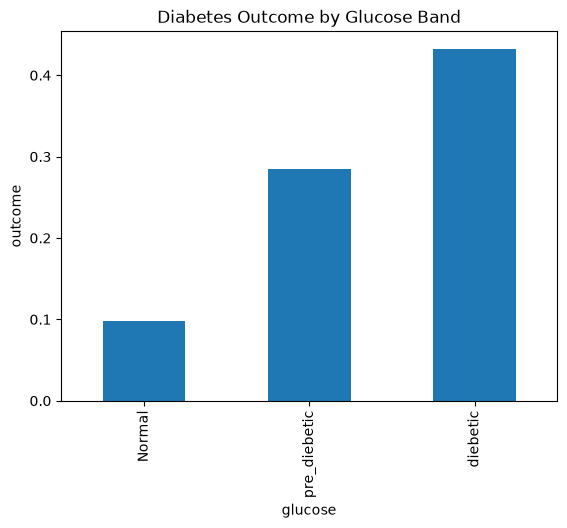

In [167]:
ax = pd.crosstab(df["glucose_band"],df["outcome"],normalize="index")[1].plot(kind = "bar")
ax.set_xlabel("glucose")
ax.set_ylabel("outcome")
ax.set_title("Diabetes Outcome by Glucose Band")

In [168]:
df.to_csv(r"C:\Users\USER\Desktop\5thsem_OJT\project1_diabeties\data\prosessed\fizan_P1W2_features.csv",index=False)

In [171]:
pd.read_csv(r"C:\Users\USER\Desktop\5thsem_OJT\project1_diabeties\data\prosessed\fizan_P1W2_features.csv")

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,...,smoker,last_checkup_date,outcome,age_band,bmi_catogory,glucose_band,insulin_glucose_ratio,pregnancies_rate,since_checkup,activity_smoker
0,P00826,79.0,male,0,124.0,71.0,30.0,124.0,23.4,0.588,...,NO,2023-04-20,0,senior,normal,pre_diebetic,1.000000,0.000000,618,Unknown/NO
1,P00108,37.0,male,0,153.0,85.0,24.0,42.0,33.9,0.192,...,YES,2024-05-03,1,middle-aged,obeese,diebetic,0.274510,0.000000,239,Medium/YES
2,P00517,39.0,female,0,142.0,68.0,22.0,159.0,26.9,0.777,...,UNKNOWN,2023-07-08,0,middle-aged,overweight,diebetic,1.119718,0.000000,539,Low/UNKNOWN
3,P00687,68.0,female,7,121.0,88.0,26.0,124.0,29.0,1.217,...,YES,2024-04-14,1,senior,overweight,pre_diebetic,1.024793,0.102941,258,Unknown/YES
4,P00927,75.0,female,0,107.0,84.0,31.0,101.0,21.2,0.278,...,NO,2024-01-27,0,senior,normal,pre_diebetic,0.943925,0.000000,336,Low/NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,P00338,64.0,male,2,117.0,81.0,34.0,124.0,40.3,0.641,...,YES,2023-11-17,0,senior,obeese,pre_diebetic,1.059829,0.031250,407,Medium/YES
946,P00092,71.0,female,0,140.0,64.0,37.0,124.0,33.4,0.116,...,YES,2023-05-20,1,senior,obeese,diebetic,0.885714,0.000000,588,Low/YES
947,P00081,40.0,female,0,130.0,73.0,26.0,258.0,20.1,0.709,...,NO,2023-06-07,0,middle-aged,normal,diebetic,1.984615,0.000000,570,Low/NO
948,P00704,52.0,female,4,123.0,76.0,22.0,189.0,38.9,0.540,...,NO,2024-06-05,0,middle-aged,obeese,pre_diebetic,1.536585,0.076923,206,High/NO
